In [3]:
import matplotlib.pyplot as plt
import numpy as np 
from time import sleep
import pandas as pd

#### Setting up DAQ and channels:

In [2]:
from pydaqmx_helper.adc import ADC
from pydaqmx_helper.dac import DAC

In [3]:
myDAC = DAC(0)

In [4]:
myADC = ADC()
myADC.addChannels([0, 1], minRange=0, maxRange=5)

Activated Channel 0
Activated Channel 1


#### Voltage/frequency calibration:

In [4]:
cal_voltages = np.linspace(0, 5, 11)
cal_frequencies = np.array([1, 1.178, 1.357, 1.537, 1.717, 1.901, 2.082, 2.263, 2.444, 2.624, 2.8])#+- 0.0005
cal_voltages

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])

In [6]:
from scipy.optimize import curve_fit

def lin(x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin, cal_voltages, cal_frequencies)
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))
print(a, b)
#covariance

a_upper = a+a_err
a_lower = a-a_err
b_upper = b+b_err
b_lower = b-b_err

0.36112727272727274 0.9974545454545448


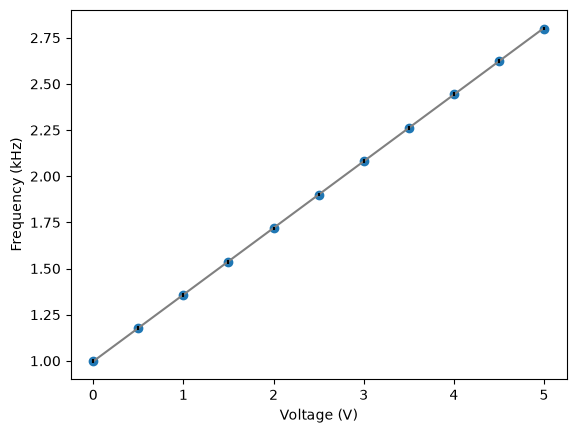

In [12]:
plt.scatter(cal_voltages, cal_frequencies)
plt.plot(cal_voltages, lin(cal_voltages, a, b), color='gray')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency (kHz)')
plt.errorbar(cal_voltages, cal_frequencies, xerr = 5/(2**12), yerr=0.01, fmt='none', color='black')
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/calibration.png", bbox_inches='tight')

In [8]:
def v2f(v):
    return lin(v, a, b)

def f2v(f):
    return (f - b)/a

In [9]:
myDAC.writeVoltage(3)
sleep(0.1)
ADC_data = myADC.sampleVoltages(100, 5000)
ch0 = ADC_data[0]
ch1 = ADC_data[1]

(0.0, 50.0)

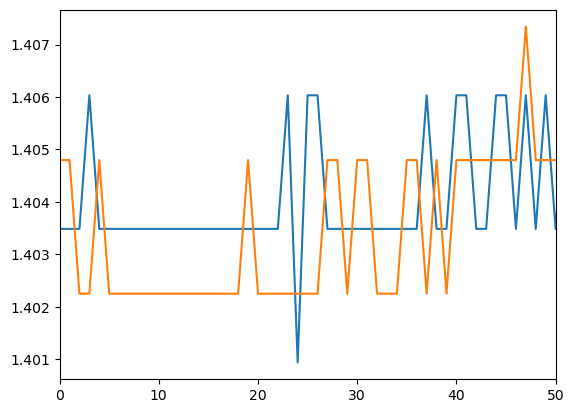

In [10]:
plt.plot(ch1)
plt.plot(ch0)
plt.xlim(0, 50)

#### Measurements & initial analysis:

In [11]:
# defining a function that gets the RMS amplitude from measurements. this also finds resonances, however these values were not used and were
#recalculated in subsequent analysis outside of the lab
def get_amp_res(freq):
    amplitudes_ch0 = []
    amplitudes_ch1 = []
    
    for f in freq:
        myDAC.writeVoltage(f2v(f))
        sleep(0.1)
        ADC_data = myADC.sampleVoltages(100, 5000)
        ch0 = ADC_data[0]
        ch1 = ADC_data[1]

        ch0 = ch0 - np.mean(ch0)
        ch1 = ch1 - np.mean(ch1)
        
        squared_ch0 = []
        squared_ch1 = []
        for i in range(len(ch0)):
            squared_ch0.append(ch0[i]**2)
            squared_ch1.append(ch1[i]**2)
    
        amp_ch0 = np.sqrt(np.mean(squared_ch0))
        amp_ch1 = np.sqrt(np.mean(squared_ch1))
        
        amplitudes_ch0.append(amp_ch0)
        amplitudes_ch1.append(amp_ch1)
        
    res_ch0 = freq[np.where(amplitudes_ch0 == np.max(amplitudes_ch0))[0]]
    res_ch1 = freq[np.where(amplitudes_ch1 == np.max(amplitudes_ch1))[0]]
    
    return res_ch0, res_ch1, amplitudes_ch0, amplitudes_ch1

In [12]:
frequency_range = np.linspace(1, 2, 500) #defining frequency range - 1 to 2 kHz

In [93]:
#setting up dataframes to store values
columns_res = ('resonance_freq_ch0', 'resonance_freq_ch1')
med_resonance_df = pd.DataFrame(columns = columns_res, index=np.arange(0, 20, 1))
med_amplitude_df_ch0 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(0, 500, 1))
med_amplitude_df_ch1 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(0, 500, 1))

In [94]:
i=0

In [112]:
#this cell was run after each time the plunger was moved to add a value for the relevant delta L (intervals given in other notebook)
res_ch0, res_ch1, amplitudes_ch0, amplitudes_ch1 = get_amp_res(frequency_range)

med_resonance_df.loc[i, 'resonance_freq_ch0'] = res_ch0
med_resonance_df.loc[i, 'resonance_freq_ch1'] = res_ch1

med_amplitude_df_ch0[i] = amplitudes_ch0
med_amplitude_df_ch1[i] = amplitudes_ch1
i+=1

In [118]:
#saving values:
med_amplitude_df_ch0.to_csv('med_amp_ch0_3.csv', index=False)
med_amplitude_df_ch1.to_csv('med_amp_ch1_3.csv', index=False)
med_resonance_df.to_csv('med_res_3.csv', index=False)

In [74]:
i=0

In [75]:
#process repeated for each diaphragm size
big_resonance_df = pd.DataFrame(columns = columns_res, index=np.arange(0, 20, 1))
big_amplitude_df_ch0 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(0, 500, 1))
big_amplitude_df_ch1 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(0, 500, 1))

In [92]:
res_ch0, res_ch1, amplitudes_ch0, amplitudes_ch1 = get_amp_res(frequency_range)

big_resonance_df.loc[i, 'resonance_freq_ch0'] = res_ch0
big_resonance_df.loc[i, 'resonance_freq_ch1'] = res_ch1

big_amplitude_df_ch0[i] = amplitudes_ch0
big_amplitude_df_ch1[i] = amplitudes_ch1
i+=1

In [96]:
big_amplitude_df_ch0.to_csv('big_amp_ch0_3.csv', index=False)
big_amplitude_df_ch1.to_csv('big_amp_ch1_3.csv', index=False)
big_resonance_df.to_csv('big_res_3.csv', index=False)

In [24]:
i=0

In [25]:
small_resonance_df = pd.DataFrame(columns = columns_res, index=np.arange(0, 20, 1))
small_amplitude_df_ch0 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(1, 2, 0.002))
small_amplitude_df_ch1 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(1, 2, 0.002))

In [43]:
res_ch0, res_ch1, amplitudes_ch0, amplitudes_ch1 = get_amp_res(frequency_range)

small_resonance_df.loc[i, 'resonance_freq_ch0'] = res_ch0
small_resonance_df.loc[i, 'resonance_freq_ch1'] = res_ch1

small_amplitude_df_ch0[i] = amplitudes_ch0
small_amplitude_df_ch1[i] = amplitudes_ch1
i+=1

In [41]:
i

13

In [45]:
small_amplitude_df_ch0.to_csv('small_amp_ch0_3.csv', index=False)
small_amplitude_df_ch1.to_csv('small_amp_ch1_3.csv', index=False)
small_resonance_df.to_csv('small_res_3.csv', index=False)

In [114]:
i=0

In [115]:
solid_resonance_df = pd.DataFrame(columns = columns_res, index=np.arange(0, 20, 1))
solid_amplitude_df_ch0 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(0, 500, 1))
solid_amplitude_df_ch1 = pd.DataFrame(columns = np.arange(0, 20, 1), index=np.arange(0, 500, 1))

In [131]:
res_ch0, res_ch1, amplitudes_ch0, amplitudes_ch1 = get_amp_res(frequency_range)

solid_resonance_df.loc[i, 'resonance_freq_ch0'] = res_ch0
solid_resonance_df.loc[i, 'resonance_freq_ch1'] = res_ch1

solid_amplitude_df_ch0[i] = amplitudes_ch0
solid_amplitude_df_ch1[i] = amplitudes_ch1
i+=1

In [132]:
solid_amplitude_df_ch0.to_csv('solid_amp_ch0_3.csv', index=False)
solid_amplitude_df_ch1.to_csv('solid_amp_ch1_3.csv', index=False)
solid_resonance_df.to_csv('solid_res_3.csv', index=False)